# Analysis
In this notebook, all of the steps from the prior notebooks are applied to all events under scrutiny. The script 'analysis_execution.py' is used to loop over all events that were part of the selection.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.stats as stats
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
import pandas as pd
from statsmodels.sandbox.stats.runs import runstest_1samp


## Subsetting ESDC
This has to be done to access ESDC locally. **Can be skipped** if already written to disk or available on cluster.

In [ ]:
# Import ESDL dataset
url = 'https://data.rsc4earth.de/download/EarthSystemDataCube/v3.0.1/esdc-8d-0.25deg-1x720x1440-3.0.1.zarr/'
ds_esdc = xr.open_zarr(url)

# Select only the variables you need
variables = ['kndvi', 'air_temperature_2m', 'min_air_temperature_2m', 
            'max_air_temperature_2m', 'precipitation_era5', 
            'root_moisture', 'evaporation', 'potential_evaporation']

ds_esdc = ds_esdc[variables]

# Restrict to the time period of interest (2000–2021)
ds_esdc = ds_esdc.sel(time=slice("2000-01-01", "2021-12-31"))

# Force load
ds_esdc = ds_esdc.compute()

# Save to local Zarr store (folder on disk)
output_path = "data/esdc_subset.zarr" 
ds_esdc.to_zarr(output_path, mode="w")

## Run computations

In [28]:
%run analysis_execution.py

Processing events:   0%|          | 0/189 [00:00<?, ?it/s]

Processing event 83007...


Processing events:   1%|          | 1/189 [01:56<6:05:10, 116.55s/it]

Processing event 104409...


Processing events:   1%|          | 2/189 [03:45<5:50:13, 112.37s/it]

...

Skipping event 104050 — empty mask
Processing event 103579...


Processing events:  99%|█████████▉| 188/189 [10:36:04<00:37, 37.42s/it]

Skipping event 103579 — empty mask
Processing event 67353...


Processing events: 100%|██████████| 189/189 [10:36:07<00:00, 201.95s/it]

Skipping event 67353 — empty mask


21 events were skipped because the land masking resulted in an empty mask, i.e. no data over land available.

## Visualize Results


In [2]:
# Load pre-computed results
df_all = pd.read_csv('data/output/26_03_04.csv', index_col=['event_label', 'veg_class'])

# Load translation df
df_translation = pd.read_csv('data/GLDA_veg_legend.csv', index_col=0)

# Get mapping from numeric class to class name
class_name_map = df_translation.iloc[:, 0].to_dict()

In [4]:
# Get statistics per veg_class
result_detailed = df_all.groupby('veg_class', as_index=False)[['resilience', 'resistance', 'recovery', 'kndvi_anomaly_strength_average']].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
result_detailed['veg_class'] = result_detailed['veg_class'].map(class_name_map)
result_detailed.index = result_detailed['veg_class']
result_detailed = result_detailed.drop(columns='veg_class')

/var/folders/50/66mz5mzd0k7gz3g2z0y80mlc0000gn/T/ipykernel_68486/2769977816.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  result_detailed = result_detailed.drop(columns='veg_class')


Transform dataframe to latex for Appendix:

In [5]:
result_detailed['resilience'].to_latex(float_format="%.3f", escape=True)

'\\begin{tabular}{lrrrrrr}\n\\toprule\n & mean & median & std & min & max & count \\\\\nveg_class &  &  &  &  &  &  \\\\\n\\midrule\nEvergreen Needleleaf Forest\xa0 & 0.971 & 0.988 & 0.064 & 0.849 & 1.100 & 22 \\\\\nEvergreen Broadleaf Forest & 1.006 & 1.006 & 0.032 & 0.892 & 1.094 & 94 \\\\\nDeciduous Needleleaf Forest\xa0 & 0.989 & 0.989 & 0.004 & 0.986 & 0.992 & 2 \\\\\nDeciduous Broadleaf Forest & 1.014 & 1.001 & 0.077 & 0.916 & 1.289 & 22 \\\\\n Mixed Forest\xa0 & 0.991 & 0.994 & 0.061 & 0.797 & 1.128 & 46 \\\\\n Closed Shrublands\xa0 & 0.949 & 0.970 & 0.128 & 0.699 & 1.136 & 10 \\\\\nOpen Shrublands\xa0 & 1.032 & 1.004 & 0.160 & 0.711 & 1.571 & 61 \\\\\nWoody Savannas & 1.022 & 1.004 & 0.080 & 0.869 & 1.282 & 48 \\\\\nSavannas & 1.021 & 1.016 & 0.094 & 0.737 & 1.219 & 49 \\\\\nGrassland & 1.025 & 1.022 & 0.100 & 0.772 & 1.274 & 74 \\\\\nPermanent Wetland & 1.065 & 1.065 & 0.066 & 1.019 & 1.112 & 2 \\\\\nCropland & 1.032 & 1.030 & 0.083 & 0.803 & 1.236 & 56 \\\\\nUrban and Built-U

### Resilience

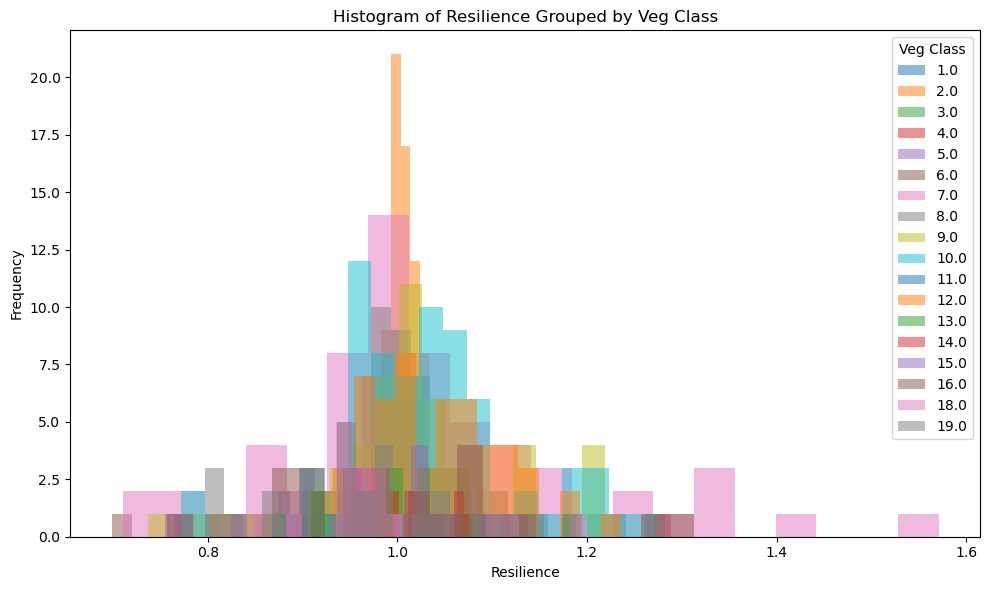

In [6]:
# Group by 'veg_class' level of the index
grouped = df_all.groupby(level='veg_class')['resilience']

# Plot histograms for each group
plt.figure(figsize=(10, 6))

for name, group in grouped:
    plt.hist(group.dropna(), bins=20, alpha=0.5, label=str(name))  # dropna for clean histogram

plt.xlabel('Resilience')
plt.ylabel('Frequency')
plt.title('Histogram of Resilience Grouped by Veg Class')
plt.legend(title='Veg Class')
plt.tight_layout()
plt.show()

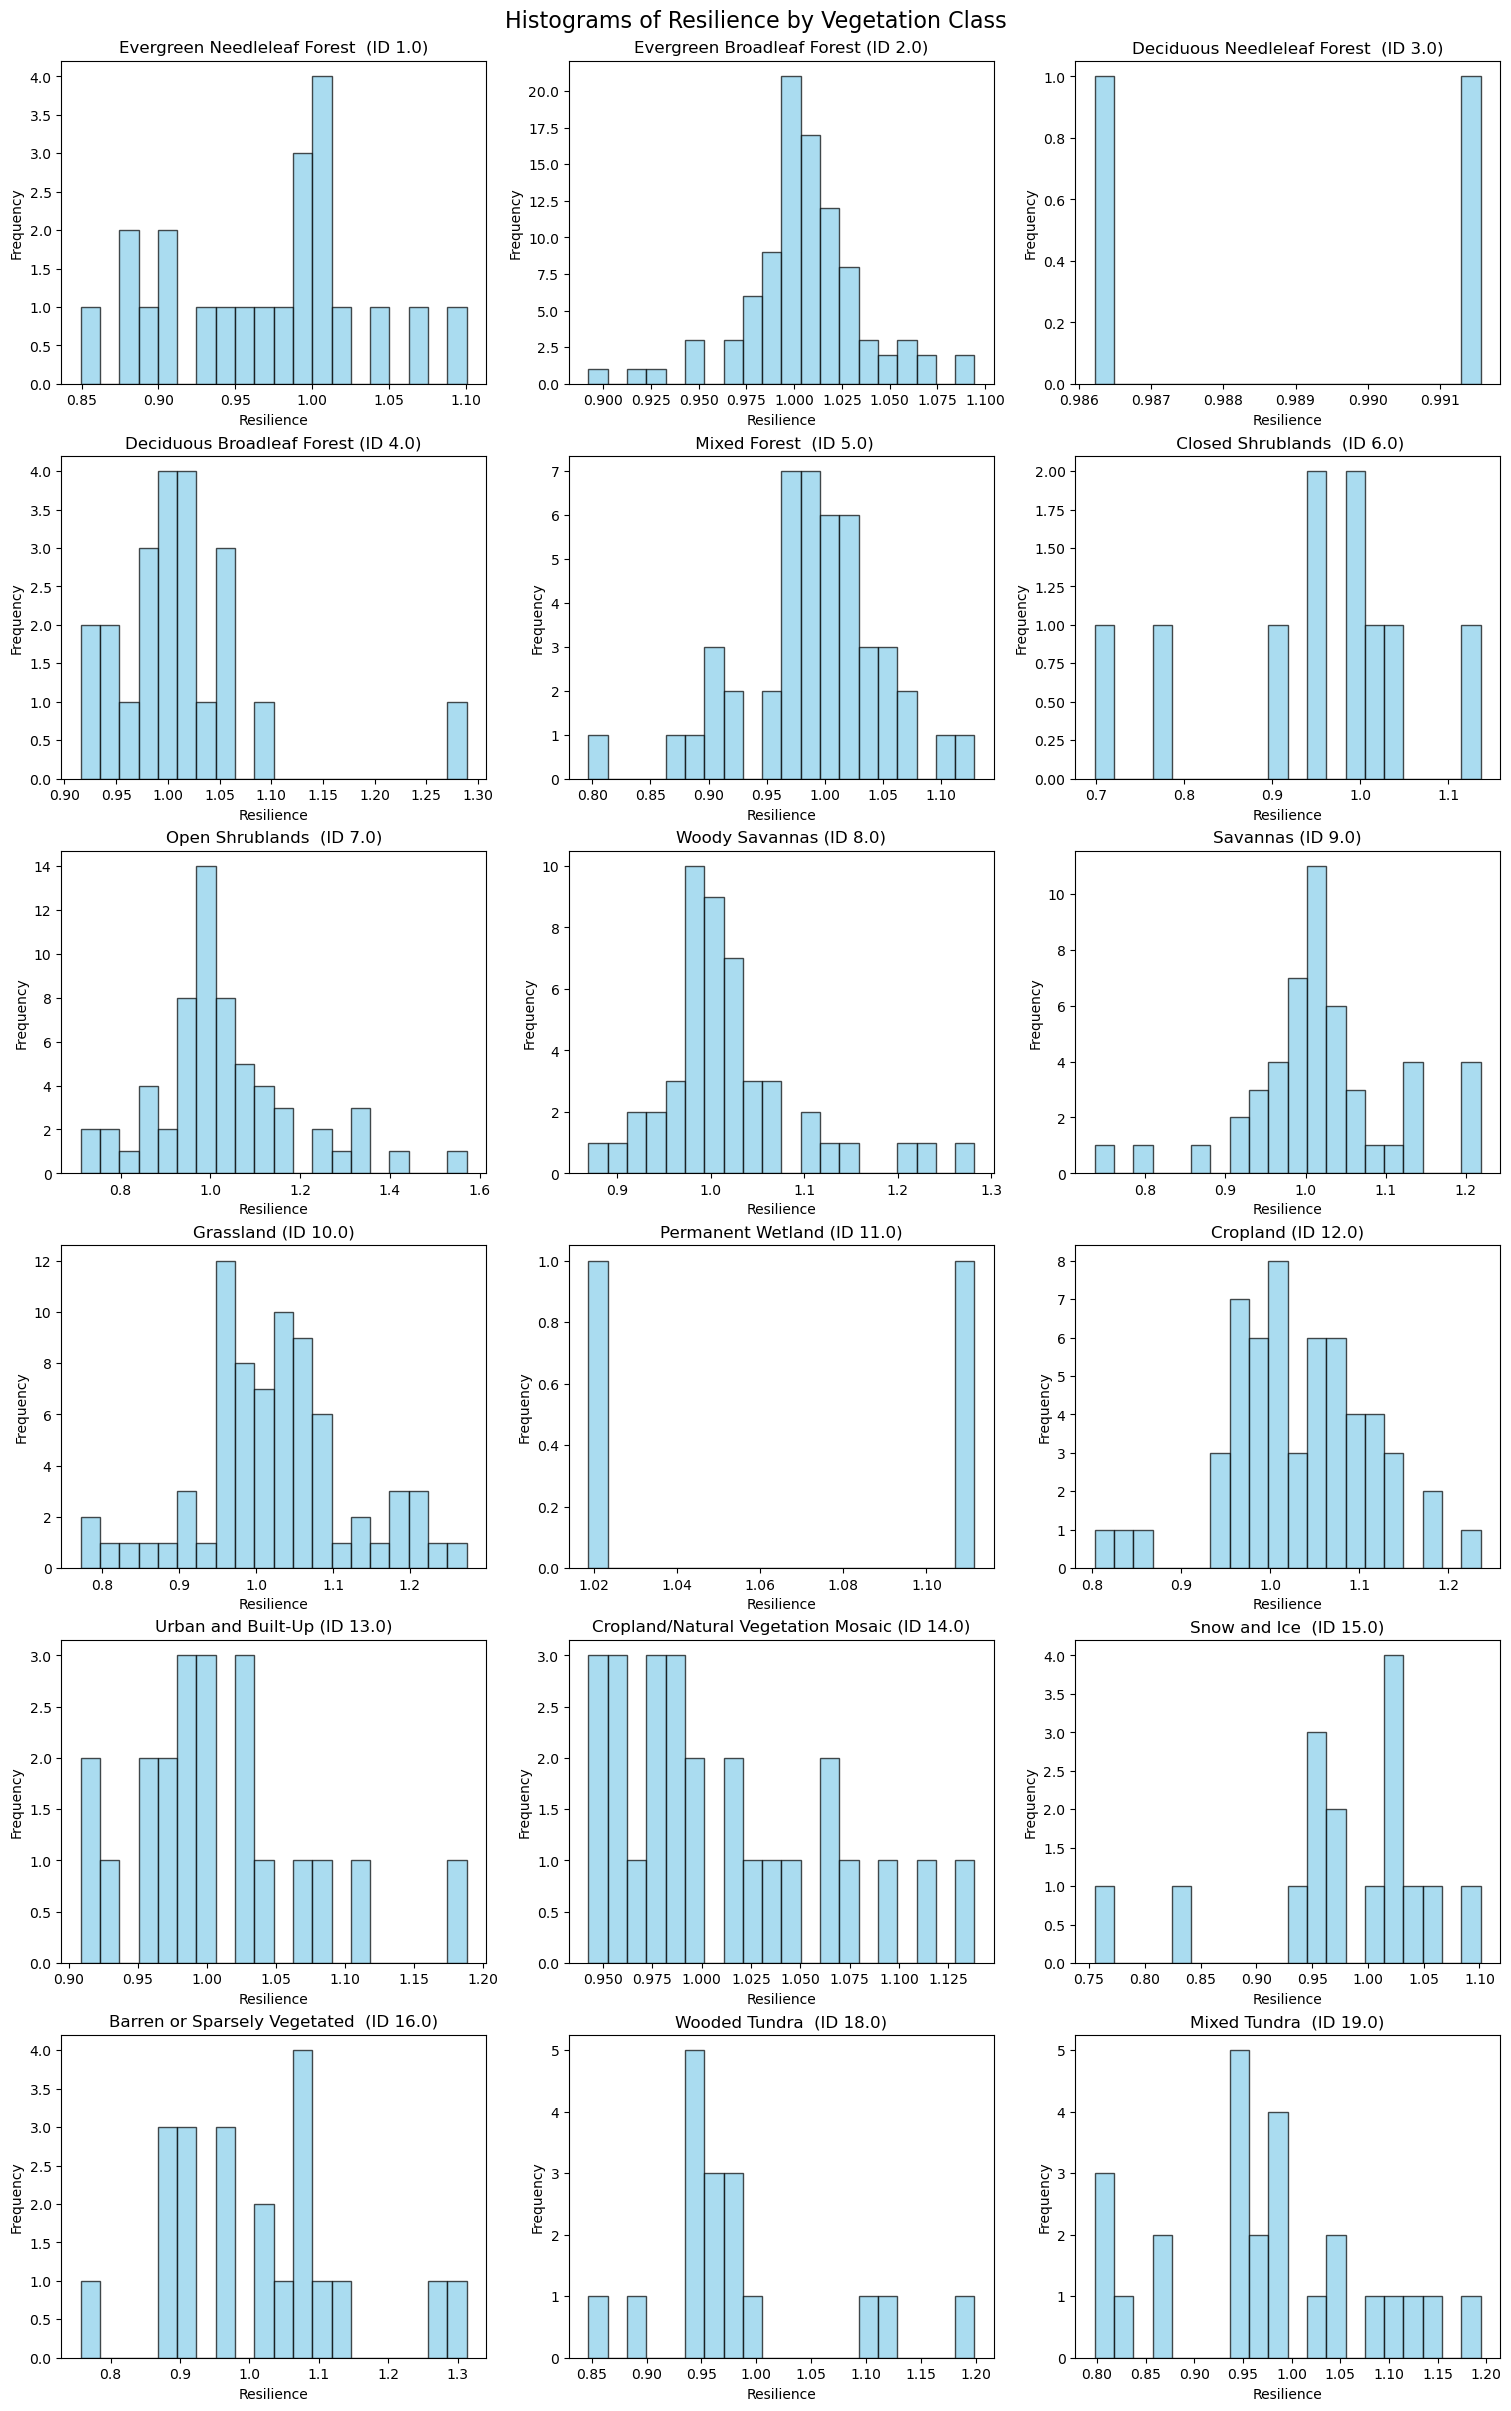

In [7]:
# Group df_all by 'veg_class' level in MultiIndex
grouped = df_all.groupby(level='veg_class')['resilience']

# Get unique veg_classes and count for subplot grid
veg_classes = list(grouped.groups.keys())
n = len(veg_classes)

# Set up subplot grid (e.g., 3 columns)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Plot each veg_class in its own subplot with translated label
for i, veg_class in enumerate(veg_classes):
    class_name = class_name_map.get(veg_class, f'Class {veg_class}')  # fallback if not found
    group = grouped.get_group(veg_class)
    
    ax = axes[i]
    ax.hist(group.dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{class_name} (ID {veg_class})')
    ax.set_xlabel('Resilience')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Resilience by Vegetation Class', fontsize=16)
plt.show()

/var/folders/50/66mz5mzd0k7gz3g2z0y80mlc0000gn/T/ipykernel_68486/1793898158.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


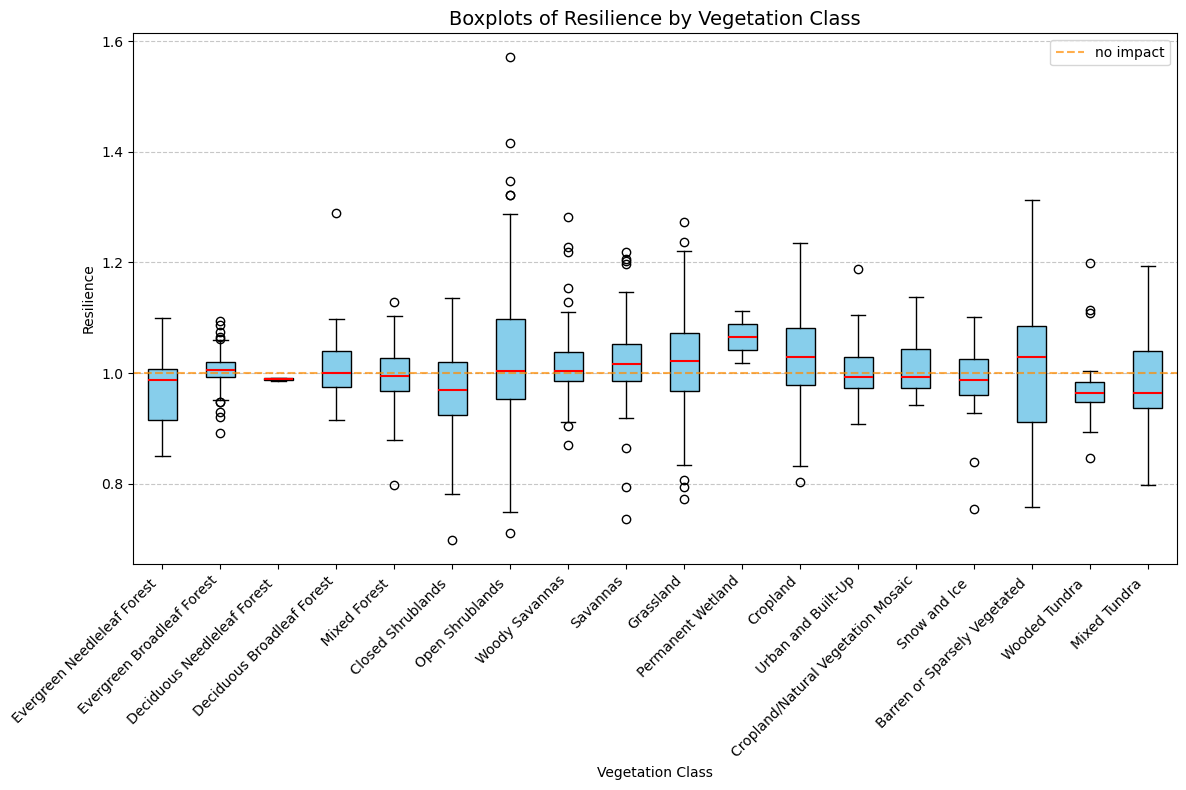

In [8]:
# Group by vegetation class
grouped = df_all.groupby(level='veg_class')['resilience']
class_name_map = df_translation.iloc[:, 0].to_dict()

# Prepare data and labels
veg_classes = list(grouped.groups.keys())
data = [grouped.get_group(vc).dropna() for vc in veg_classes]
labels = [class_name_map.get(vc, f'Class {vc}') for vc in veg_classes]

# Boxplots
plt.figure(figsize=(12, 8))
bp = plt.boxplot(
    data,
    labels=labels,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='black'),
    medianprops=dict(color='red', linewidth=1.5)
)

plt.title('Boxplots of Resilience by Vegetation Class', fontsize=14)
plt.xlabel('Vegetation Class')
plt.ylabel('Resilience')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(1, color='darkorange', linestyle='--', alpha=0.7, label='no impact')
plt.legend()


plt.tight_layout()
plt.show()


### Resistance

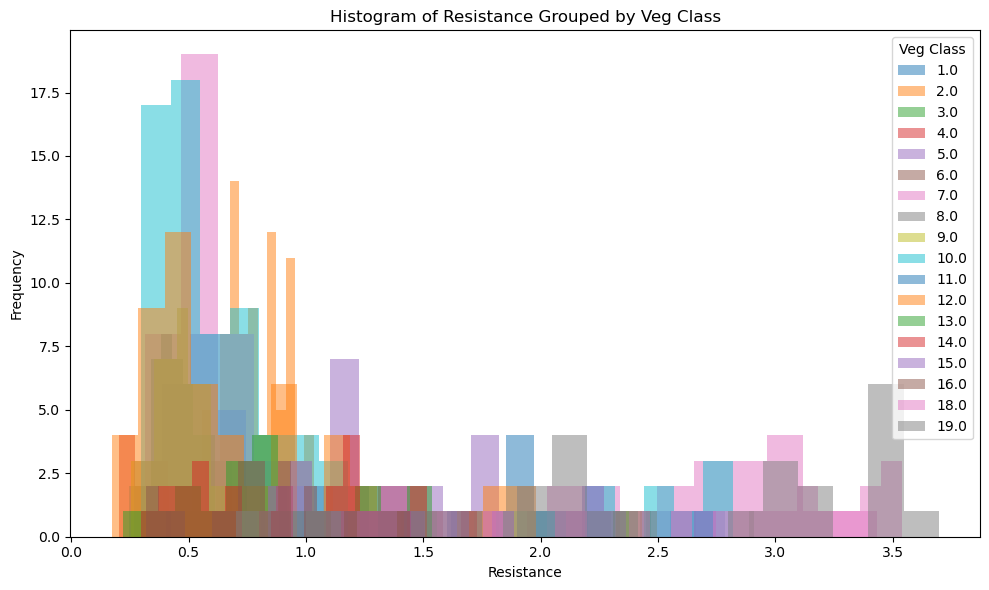

In [9]:
# Group by 'veg_class' level of the index
grouped_resist = df_all.groupby(level='veg_class')['resistance']

# Plot histograms for each group
plt.figure(figsize=(10, 6))

for name, group in grouped_resist:
    plt.hist(group.dropna(), bins=20, alpha=0.5, label=str(name))  # dropna for clean histogram

plt.xlabel('Resistance')
plt.ylabel('Frequency')
plt.title('Histogram of Resistance Grouped by Veg Class')
plt.legend(title='Veg Class')
plt.tight_layout()
plt.show()

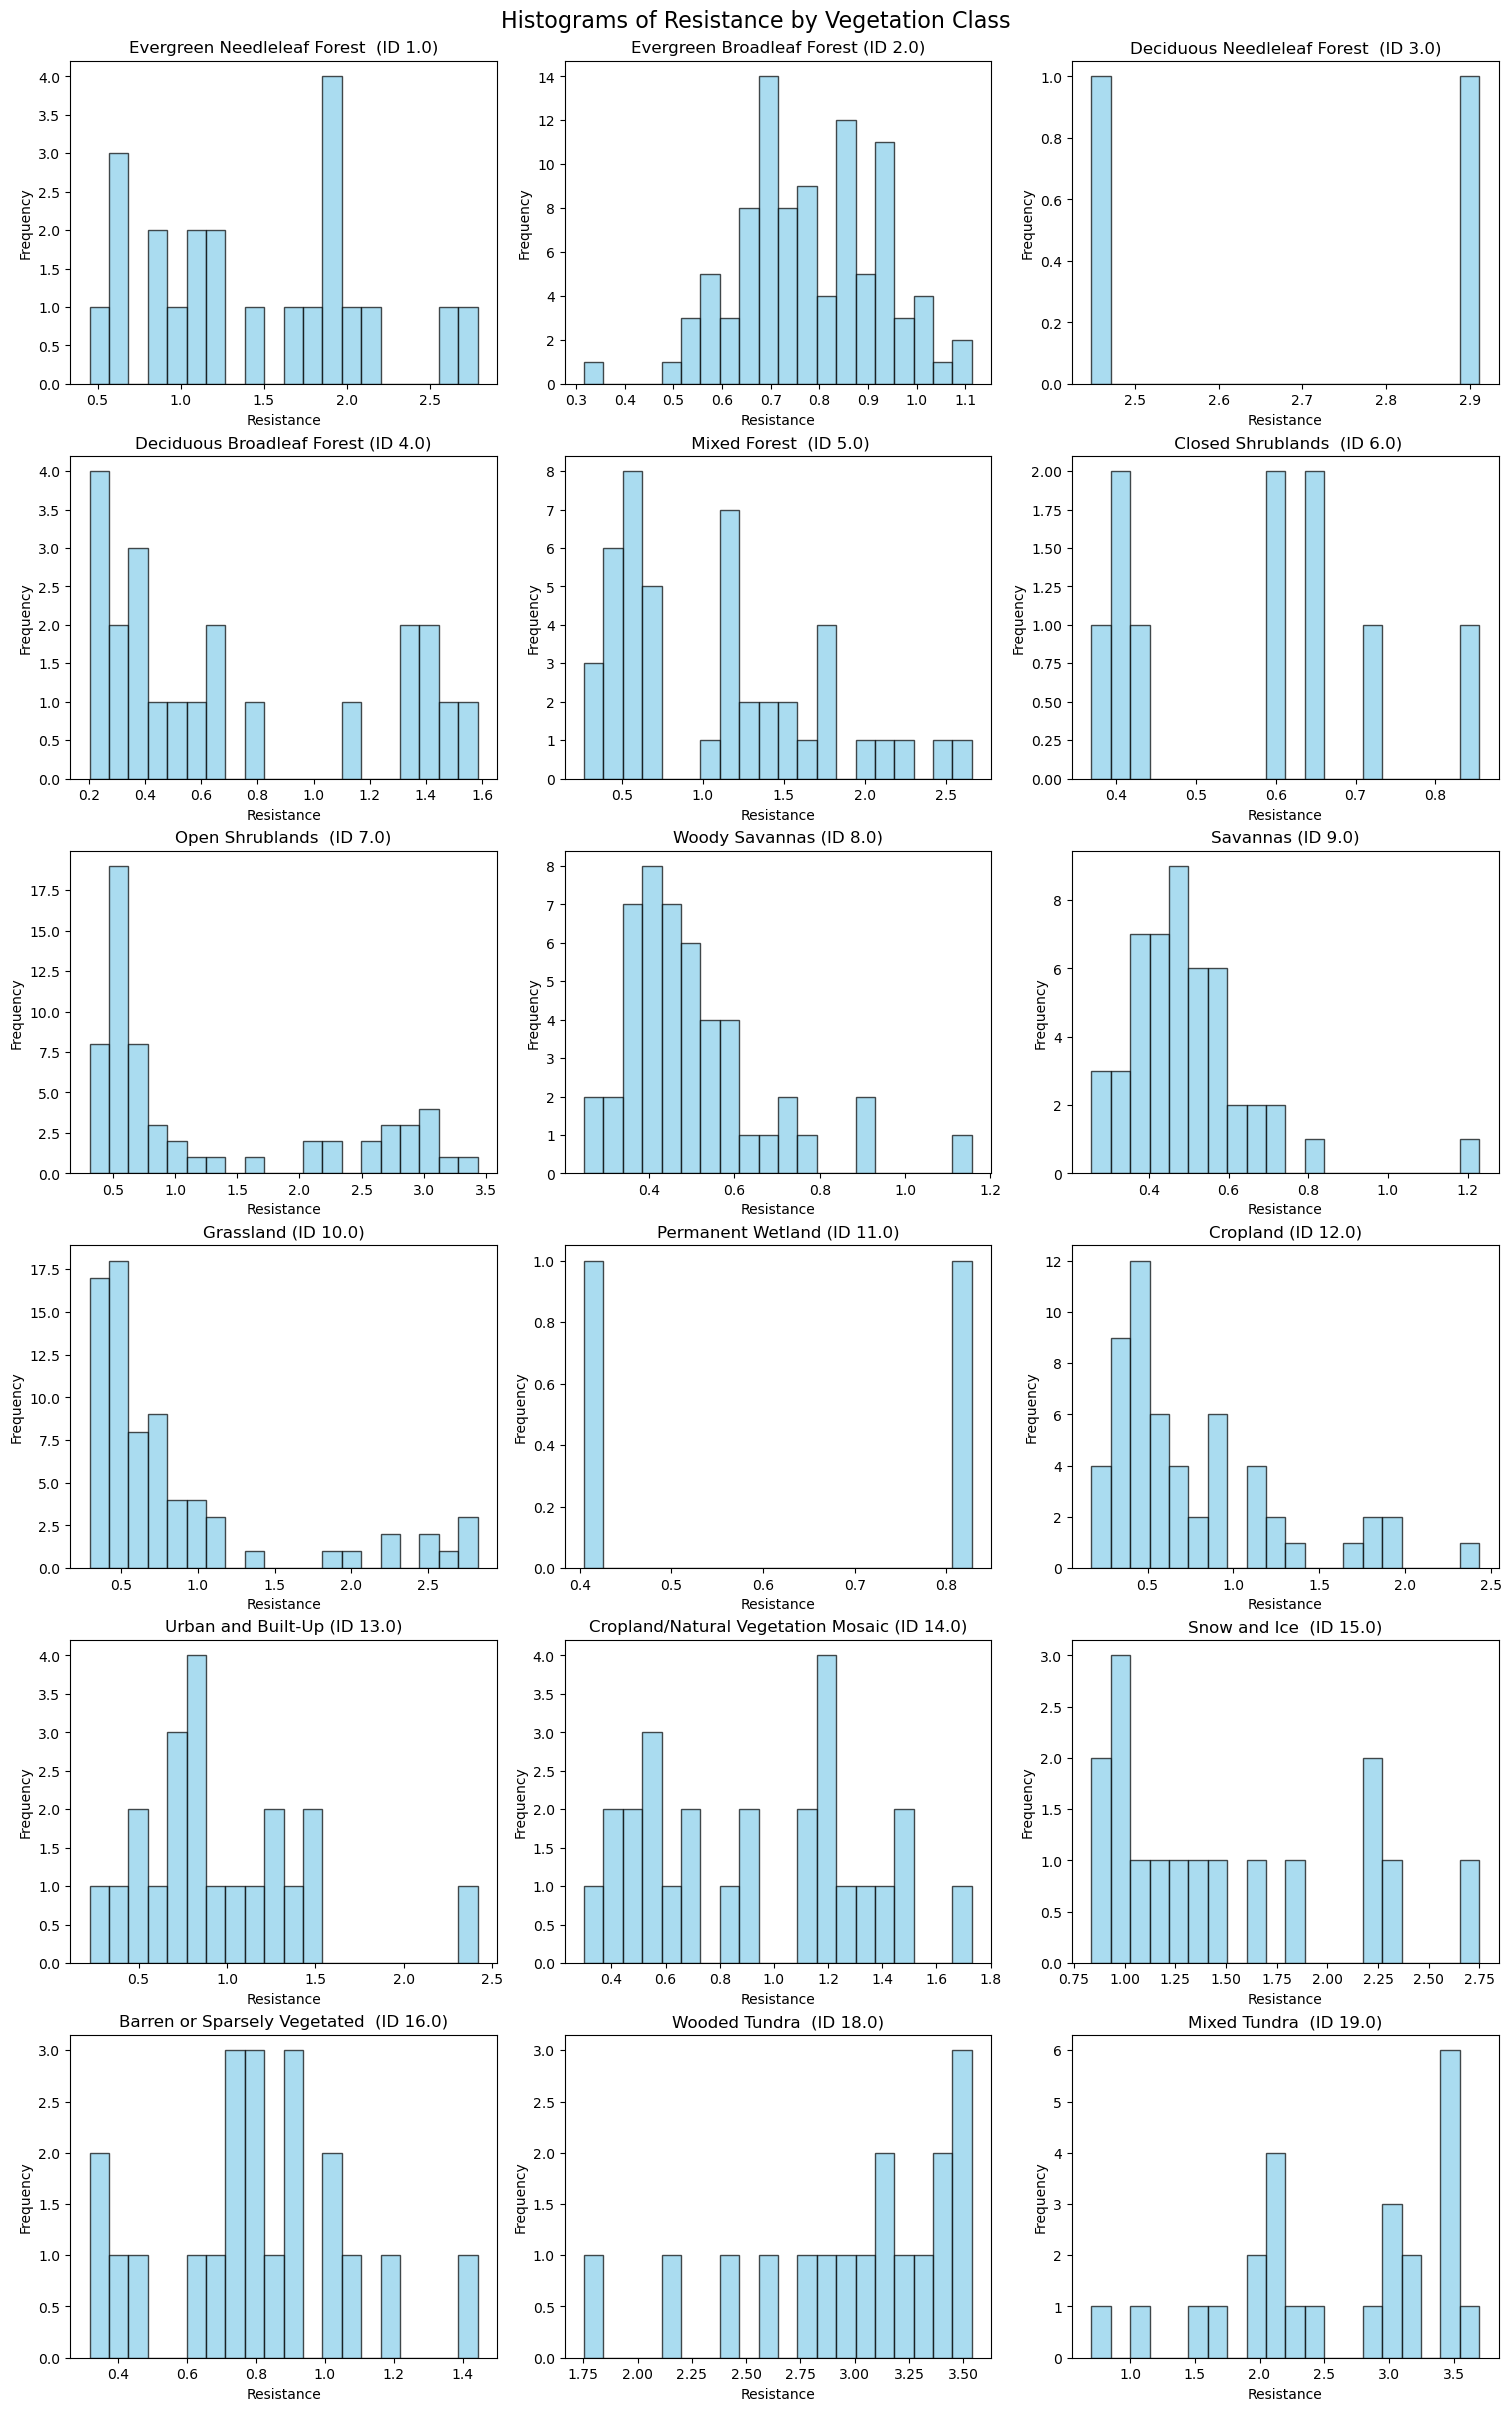

In [10]:
# Get mapping from numeric class to class name
class_name_map = df_translation.iloc[:, 0].to_dict()

# Group df_all by 'veg_class' level in MultiIndex
grouped = df_all.groupby(level='veg_class')['resistance']

# Get unique veg_classes and count for subplot grid
veg_classes = list(grouped.groups.keys())
n = len(veg_classes)

# Set up subplot grid (e.g., 3 columns)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Plot each veg_class in its own subplot with translated label
for i, veg_class in enumerate(veg_classes):
    class_name = class_name_map.get(veg_class, f'Class {veg_class}')  # fallback if not found
    group = grouped.get_group(veg_class)
    
    ax = axes[i]
    ax.hist(group.dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{class_name} (ID {veg_class})')
    ax.set_xlabel('Resistance')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Resistance by Vegetation Class', fontsize=16)
plt.show()

/var/folders/50/66mz5mzd0k7gz3g2z0y80mlc0000gn/T/ipykernel_68486/410666119.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


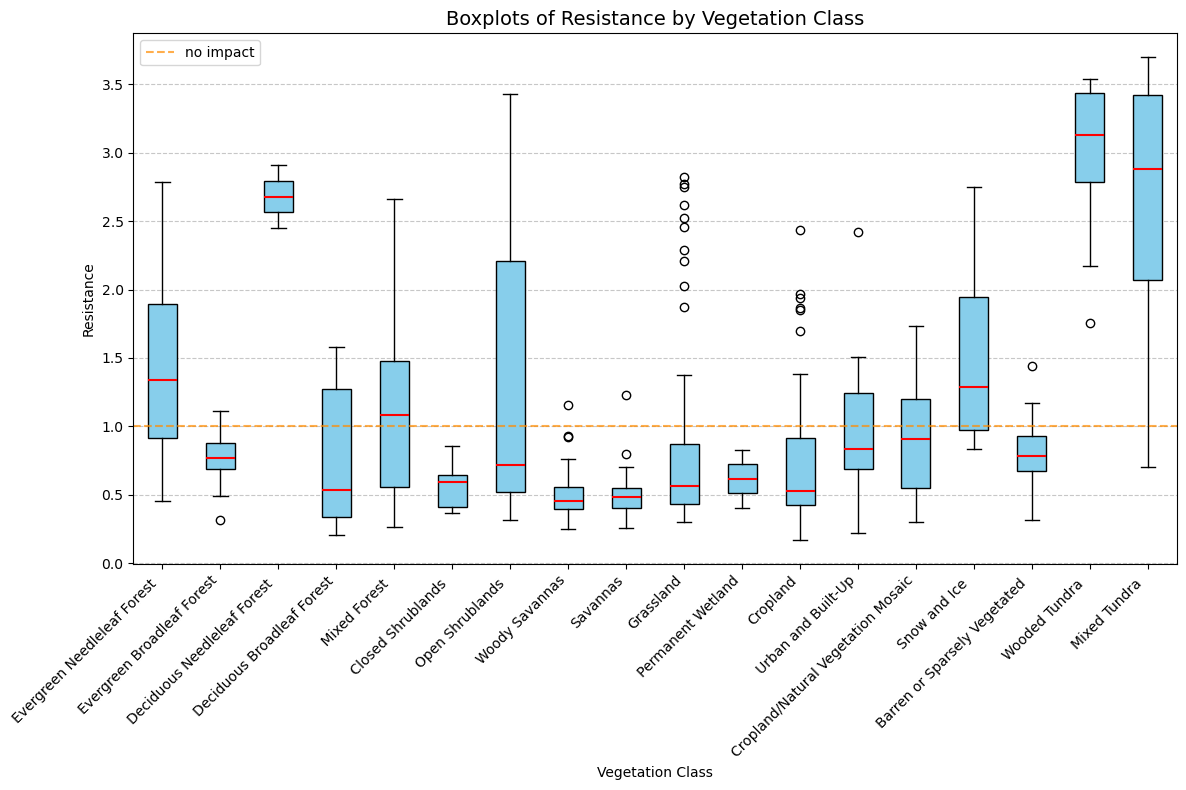

In [11]:
# Group by vegetation class
grouped = df_all.groupby(level='veg_class')['resistance']
class_name_map = df_translation.iloc[:, 0].to_dict()

# Prepare data and labels
veg_classes = list(grouped.groups.keys())
data = [grouped.get_group(vc).dropna() for vc in veg_classes]
labels = [class_name_map.get(vc, f'Class {vc}') for vc in veg_classes]

# Combined boxplot
plt.figure(figsize=(12, 8))
bp = plt.boxplot(
    data,
    labels=labels,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='black'),
    medianprops=dict(color='red', linewidth=1.5)
)

plt.title('Boxplots of Resistance by Vegetation Class', fontsize=14)
plt.xlabel('Vegetation Class')
plt.ylabel('Resistance')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=1, color='darkorange', linestyle='--', alpha=0.7, label='no impact')
plt.legend()

plt.tight_layout()
plt.show()


### Recovery

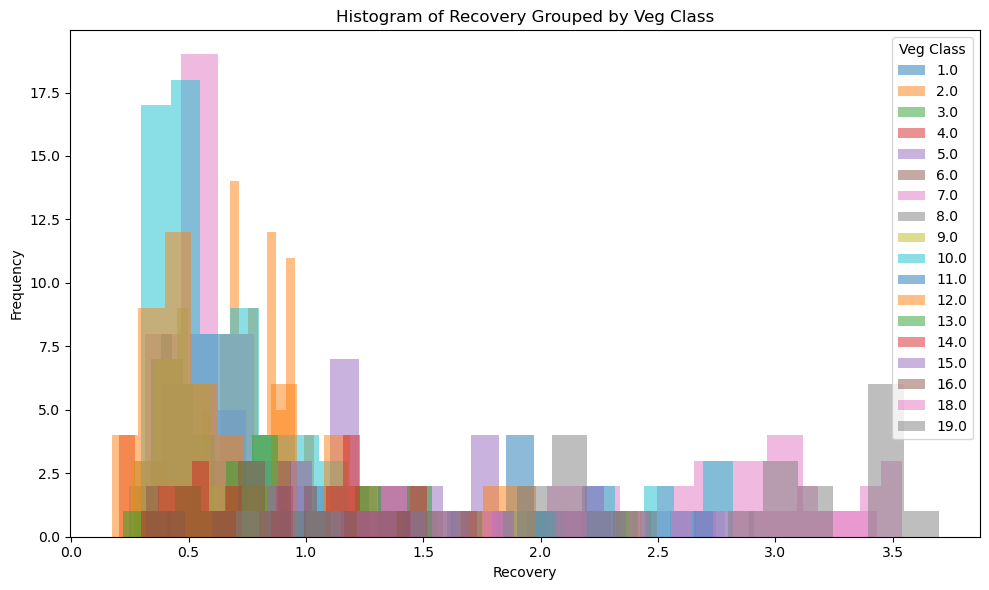

In [12]:
# Group by 'veg_class' level of the index
grouped_recov = df_all.groupby(level='veg_class')['recovery']

# Plot histograms for each group
plt.figure(figsize=(10, 6))

for name, grouped_recov in grouped:
    plt.hist(grouped_recov.dropna(), bins=20, alpha=0.5, label=str(name))  # dropna for clean histogram

plt.xlabel('Recovery')
plt.ylabel('Frequency')
plt.title('Histogram of Recovery Grouped by Veg Class')
plt.legend(title='Veg Class')
plt.tight_layout()
plt.show()

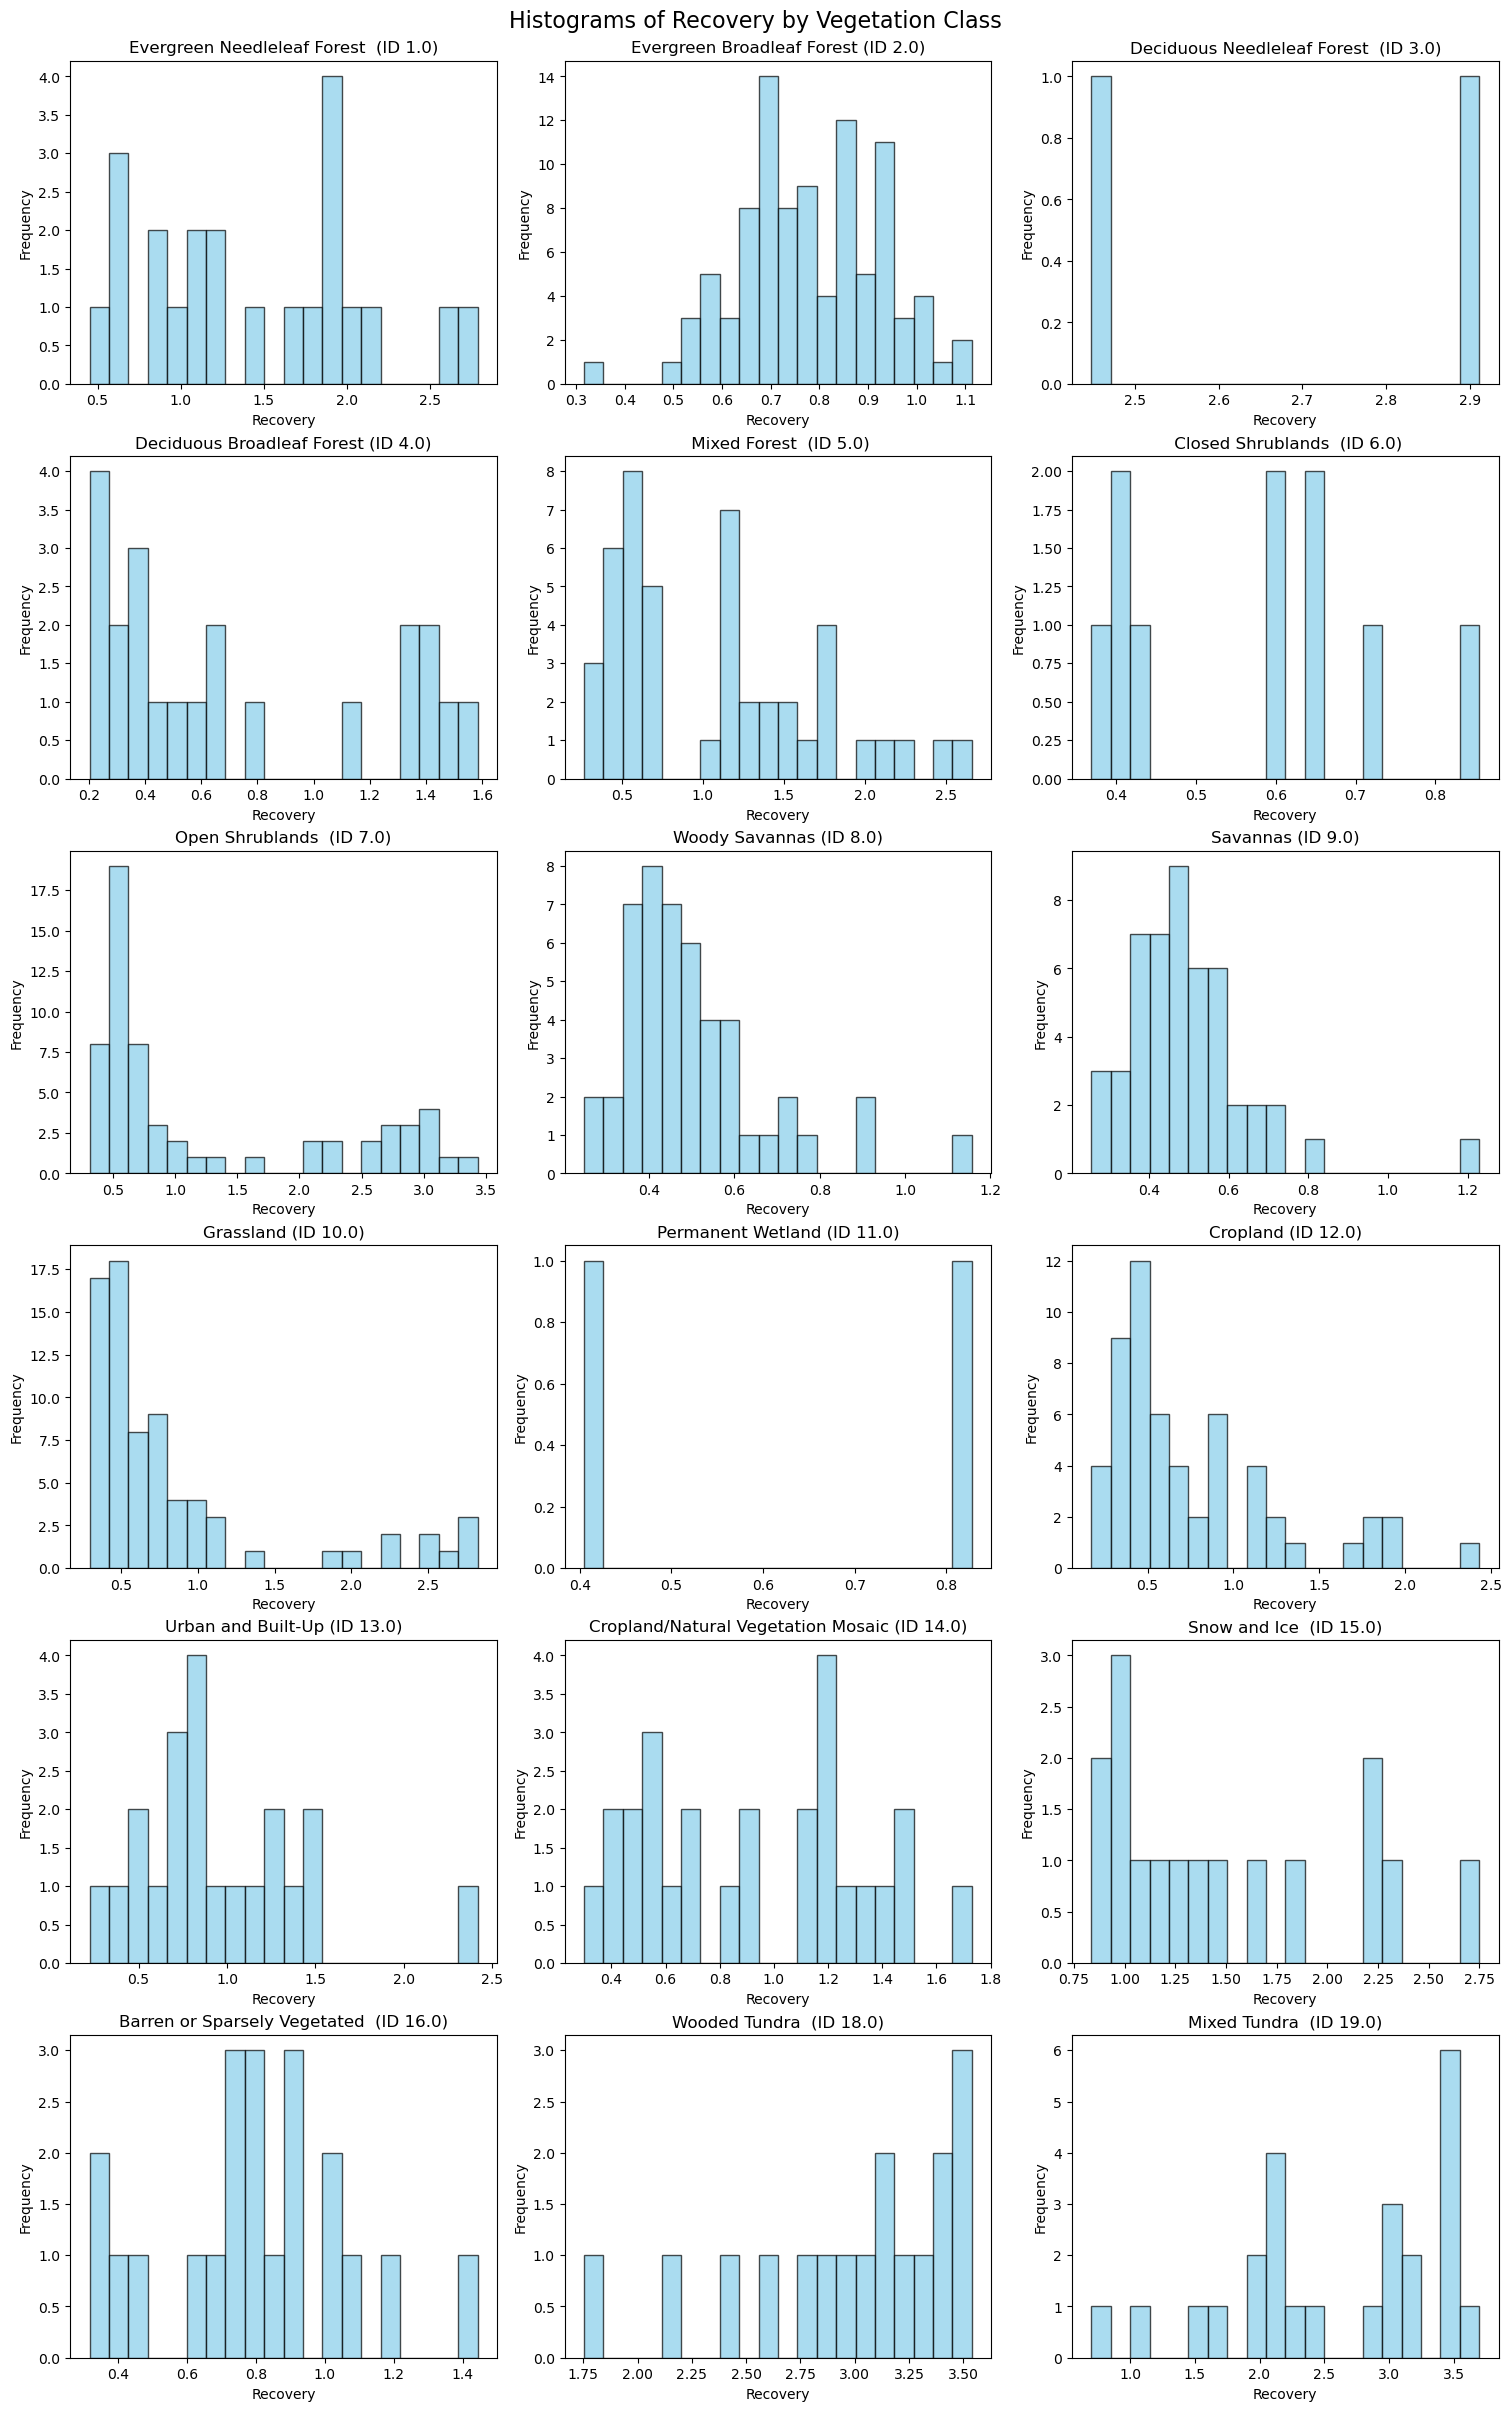

In [13]:
# Get mapping from numeric class to class name
class_name_map = df_translation.iloc[:, 0].to_dict()

# Get unique veg_classes and count for subplot grid
veg_classes = list(grouped.groups.keys())
n = len(veg_classes)

# Set up subplot grid (e.g., 3 columns)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Plot each veg_class in its own subplot with translated label
for i, veg_class in enumerate(veg_classes):
    class_name = class_name_map.get(veg_class, f'Class {veg_class}')  # fallback if not found
    group = grouped.get_group(veg_class)
    
    ax = axes[i]
    ax.hist(group.dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{class_name} (ID {veg_class})')
    ax.set_xlabel('Recovery')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Recovery by Vegetation Class', fontsize=16)
plt.show()

/var/folders/50/66mz5mzd0k7gz3g2z0y80mlc0000gn/T/ipykernel_68486/995324754.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


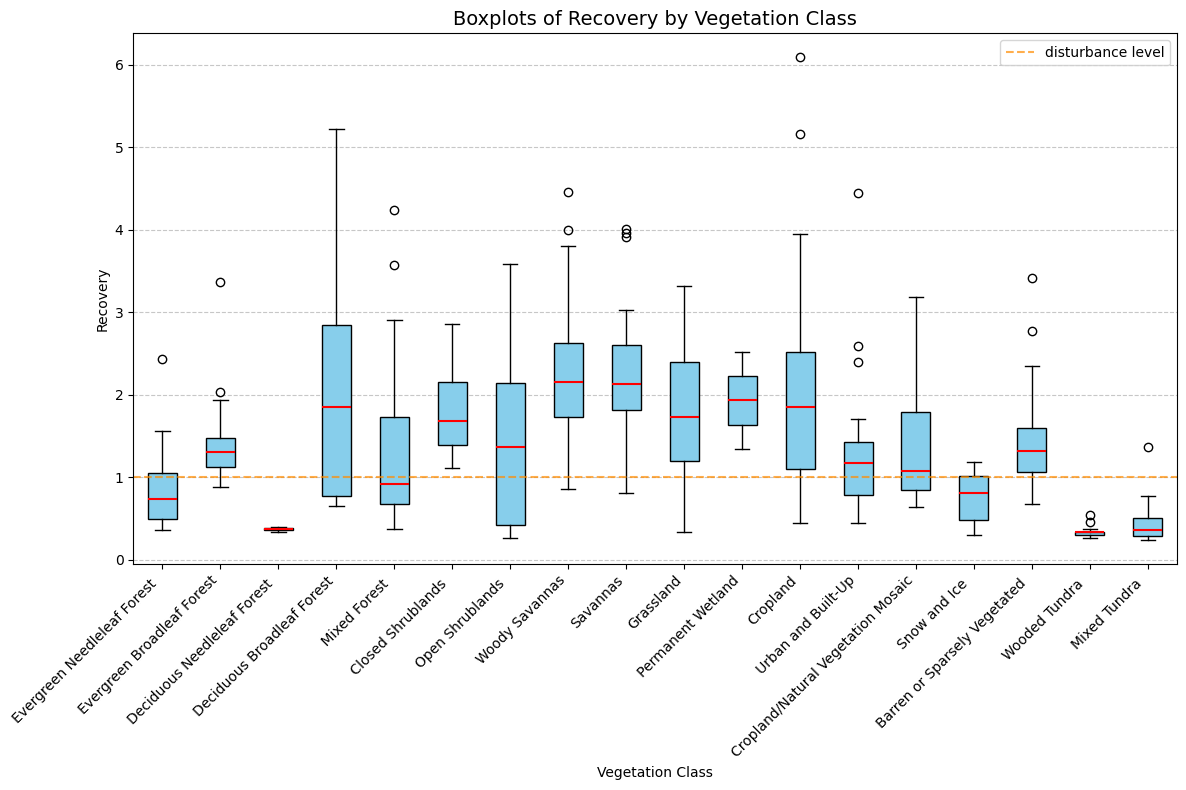

In [14]:
# Group by vegetation class
grouped = df_all.groupby(level='veg_class')['recovery']
class_name_map = df_translation.iloc[:, 0].to_dict()

# Prepare data and labels
veg_classes = list(grouped.groups.keys())
data = [grouped.get_group(vc).dropna() for vc in veg_classes]
labels = [class_name_map.get(vc, f'Class {vc}') for vc in veg_classes]

# Combined boxplot
plt.figure(figsize=(12, 8))
bp = plt.boxplot(
    data,
    labels=labels,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='black'),
    medianprops=dict(color='red', linewidth=1.5)
)

plt.title('Boxplots of Recovery by Vegetation Class', fontsize=14)
plt.xlabel('Vegetation Class')
plt.ylabel('Recovery')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=1, color='darkorange', linestyle='--', alpha=0.7, label='disturbance level')
plt.legend()

plt.tight_layout()
plt.show()


### kNDVI Anomaly

/var/folders/50/66mz5mzd0k7gz3g2z0y80mlc0000gn/T/ipykernel_68486/1356577362.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


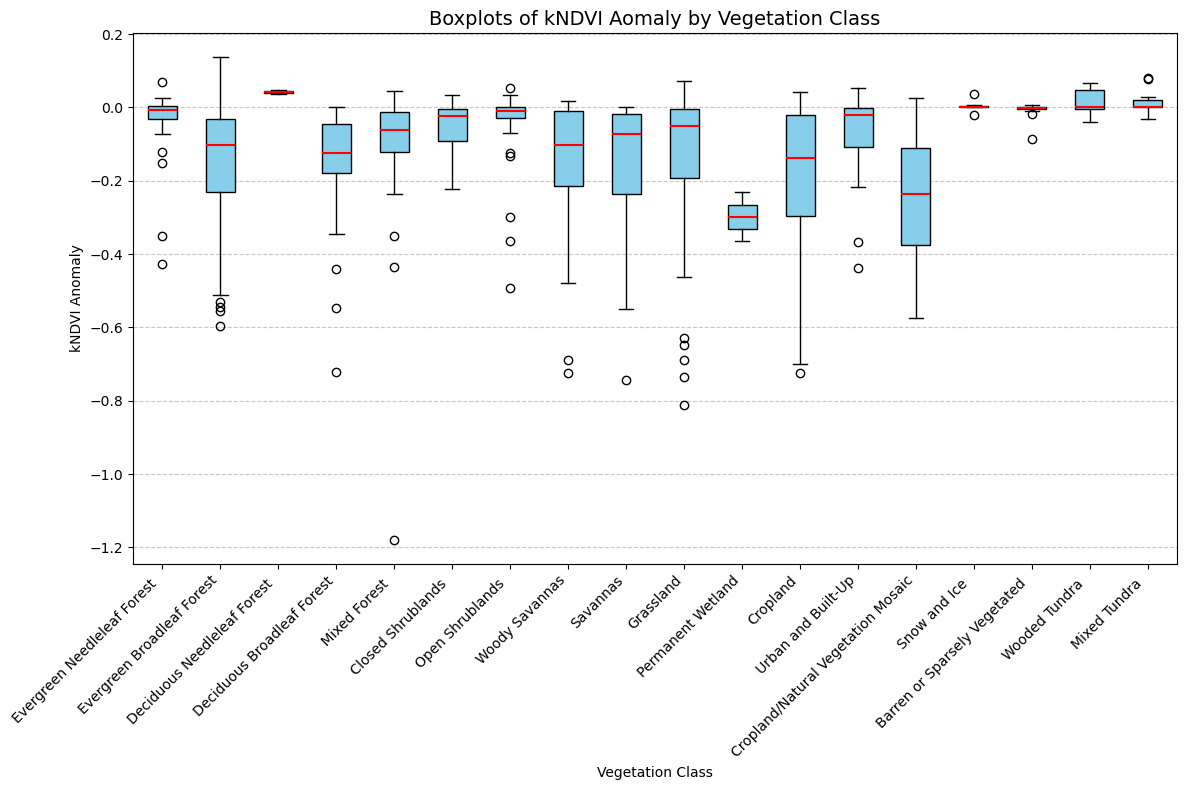

In [15]:
# Group by vegetation class
grouped = df_all.groupby(level='veg_class')['kndvi_anomaly_strength']
class_name_map = df_translation.iloc[:, 0].to_dict()

# Prepare data and labels
veg_classes = list(grouped.groups.keys())
data = [grouped.get_group(vc).dropna() for vc in veg_classes]
labels = [class_name_map.get(vc, f'Class {vc}') for vc in veg_classes]

# Combined boxplot
plt.figure(figsize=(12, 8))
bp = plt.boxplot(
    data,
    labels=labels,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='black'),
    medianprops=dict(color='red', linewidth=1.5)
)

plt.title('Boxplots of kNDVI Aomaly by Vegetation Class', fontsize=14)
plt.xlabel('Vegetation Class')
plt.ylabel('kNDVI Anomaly')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## Combined boxplots for the document

In [16]:
# List of metrics and their plotting parameters
plot_params = [
    {
        'metric': 'resilience',
        'title': 'Resilience',
        'ylabel': 'Resilience',
        'hline_y': 1,
        'hline_label': 'no impact',
        'hline_color': 'blue',
    },
    {
        'metric': 'resistance',
        'title': 'Resistance',
        'ylabel': 'Resistance',
        'hline_y': 1,
        'hline_label': 'no impact',
        'hline_color': 'blue',
    },
    {
        'metric': 'recovery',
        'title': 'Recovery',
        'ylabel': 'Recovery',
        'hline_y': 1,
        'hline_label': 'disturbance level',
        'hline_color': 'blue',
    },
    {
        'metric': 'kndvi_anomaly_strength_average',
        'title': 'Mean kNDVI Anomaly',
        'ylabel': 'Mean kNDVI Anomaly',
        'hline_y': 0,
        'hline_label': 'baseline',
        'hline_color': 'blue',
    }
]

# Prepare data and labels once (assuming all metrics share the same groups/labels)
metric = plot_params[0]['metric']
grouped = df_all.groupby(level='veg_class')[metric]
class_name_map = df_translation.iloc[:, 0].to_dict() 
veg_classes = list(grouped.groups.keys())
labels = [class_name_map.get(vc, f'Class {vc}') for vc in veg_classes]

data_list = []
for params in plot_params:
    metric = params['metric']
    grouped = df_all.groupby(level='veg_class')[metric]
    data = [grouped.get_group(vc).dropna() for vc in veg_classes]
    data_list.append(data)

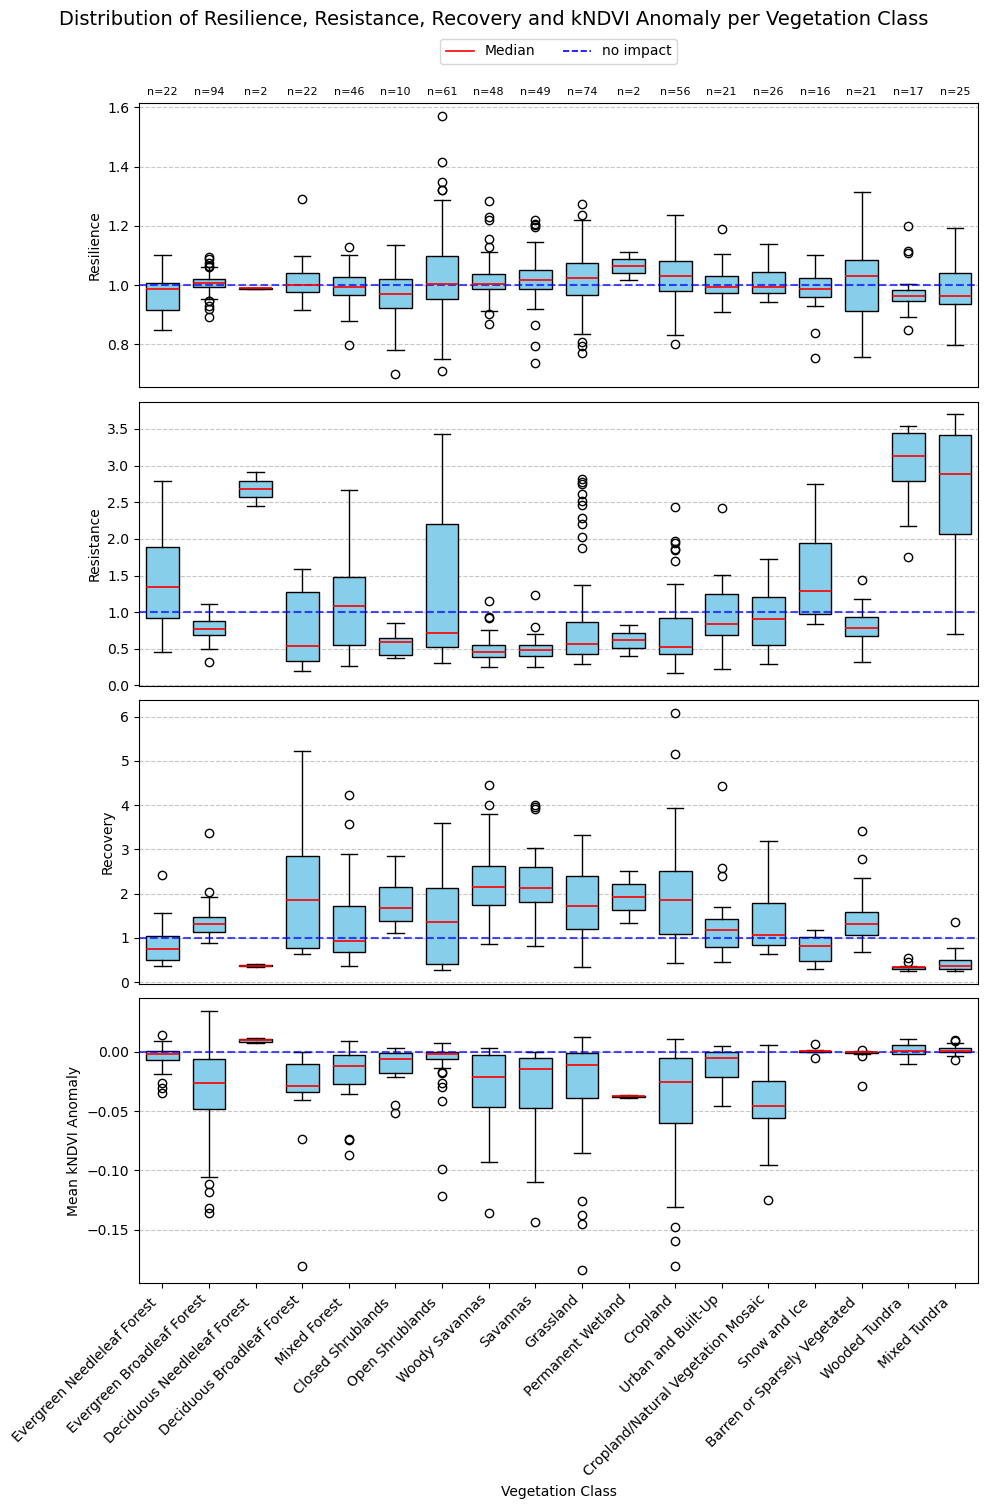

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True)

for i, ax in enumerate(axes):
    params = plot_params[i]
    data = data_list[i]

    # Boxplot
    bp = ax.boxplot(
        data,
        vert=True,
        patch_artist=True,
        widths=0.7,
        showmeans=False,  # mean removed
        boxprops=dict(facecolor='skyblue', color='black'),
        medianprops=dict(color='red', linewidth=1.2)
    )

    # Labels, grid, horizontal reference line
    ax.set_ylabel(params['ylabel'])
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    ax.axhline(
        y=params['hline_y'],
        color=params['hline_color'],
        linestyle='--',
        alpha=0.7
    )

    # X-axis tick labels
    if i < len(axes) - 1:
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.tick_params(axis='x', which='both', length=0)
    else:
        ax.set_xlabel('Vegetation Class')
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=45, ha='right')

# Resilience subplot
top_ax = axes[0]

# Annotate n above the subplot 
for j, series in enumerate(data_list[0], start=1):
    n = len(series)
    top_ax.text(
        j, 1.02, f"n={n}",
        transform=top_ax.get_xaxis_transform(),  # x=data, y=axes
        ha='center',
        va='bottom',
        fontsize=8
    )

# Combined legend
median_line = Line2D([0], [0], color='red', lw=1.2, linestyle='-', label='Median')
ref_line = Line2D(
    [0], [0],
    color=plot_params[0]['hline_color'],
    linestyle='--',
    lw=1.2,
    label=plot_params[0]['hline_label']
)

axes[0].legend(
    handles=[median_line, ref_line],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2
)

# Figure-level title
fig.suptitle(
    "Distribution of Resilience, Resistance, Recovery and kNDVI Anomaly per Vegetation Class",
    fontsize=14,
    y=0.94
)

# Layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.05)

# Export figure
output_path = '../document/Images/boxplots.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()